# <p style="text-align: center;">Logistic Regression</p>

In [1]:
#!pip install cartopy
#!pip install imageio 

## Import libraries

In [2]:
import pandas as pd
import numpy as np

import glob
import os

import requests

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import zipfile

#import xarray as xr

import folium
from folium.plugins import MarkerCluster

import pandas as pd
#from geopy.geocoders import Nominatim

import geopandas as gpd
#import cartopy.crs as ccrs

#import imageio

from sklearn.neighbors import KDTree
from sklearn.neighbors import BallTree

## Set parameters

In [3]:
decree_filename_base = 'arrete_'
decrees_folder_name = './../../data/raw/decrees'
communes_folder_name = './../../data/raw/opendatasoft'
weather_folder_name = './../../data/raw/weather/era5'
weather_ncfiles_folder_name = './../../data/raw/weather/era5/ncfiles'
processed_data_folder_name = './../../data/processed'
maps_folder_name = './../../data/processed/maps'
decrees_filename = 'decrees.parquet'
decrees_locations_filename = 'decrees_locations.parquet'
communes_csv_filename = 'correspondance-code-insee-code-postal.csv'
weather_filename = 'weather.parquet'
weather_shema = 'weather_shema.csv'
weather_decrees_filename = 'weather_decrees.parquet'
weather_decrees_shema = 'weather_decrees.csv'
#weather_zip_file = "193fcd51a8958175843ecbbcaba057c8.zip"

## Load Weather data

| Column    | Description                                      |
|-----------|--------------------------------------------------|
| date      | The date of the observation.                     |
| latitude  | The latitude coordinate of the observation point.|
| longitude | The longitude coordinate of the observation point.|
| number    | A unique identifier for the observation.         |
| expver    | Experiment version number.                       |
| u10       | 10-meter U-component of wind (eastward wind).    |
| v10       | 10-meter V-component of wind (northward wind).   |
| t2m       | 2-meter temperature (air temperature at 2 meters above the surface).|
| sp        | Surface pressure.                                |
| tp        | Total precipitation.                             |
| e         | Evaporation.                                     |
| sro       | Surface runoff.                                  |
| tcrw      | Total column water vapor.                        |
| stl1      | Soil temperature level 1.                        |
| stl2      | Soil temperature level 2.                        |
| slt       | Soil type.                                       |
| swvl1     | Volumetric soil water layer 1.                   |
| swvl2     | Volumetric soil water layer 2.                   |
| cvh       | High vegetation cover.                           |
| cvl       | Low vegetation cover.                            |
| tvh       | High vegetation type.                            |
| tvl       | Low vegetation type.                             |


## Import Data

In [4]:
# read the dataframe from parquet
import pandas as pd

df = pd.read_parquet(os.path.join(processed_data_folder_name, weather_decrees_filename))




In [5]:
os.path.join(processed_data_folder_name, weather_decrees_shema)

'./../../data/processed/weather_decrees.csv'

In [6]:
# Load the schema (data types) from the file
schema = pd.read_csv(os.path.join(processed_data_folder_name, weather_decrees_shema), index_col=0).squeeze("columns")

In [7]:
# Apply the schema to the loaded dataframe
df = df.astype(schema.to_dict())

In [8]:
df.head()

,date_1,latitude_1,longitude_1,u10_1,v10_1,t2m_1,sp_1,tp_1,e_1,sro_1,...,Code Arrondissement_2,Code Département_2,Code Région_2,start_event_year_2,latitude_2,longitude_2,year_2,latitude_rad_2,longitude_rad_2,distance_km
201,1990-01-01,51.25,2.50,4.651482,6.094338,7.558984,101673.1875,0.002449,-0.001736,3.814697e-06,...,4.0,59,31.0,1989,51.073044,2.527649,1990,0.891393,0.044116,19.770879
254,1990-01-01,51.00,1.50,5.272575,6.298440,8.234766,101567.1875,0.003467,-0.001933,9.536743e-07,...,3.0,62,31.0,1990,50.888336,1.682486,1990,0.888169,0.029365,17.822208
255,1990-01-01,51.00,1.75,4.917595,6.070413,7.896875,101591.1875,0.003078,-0.001807,1.049042e-05,...,6.0,62,31.0,1989,50.950207,1.875756,1990,0.889249,0.032738,10.400898
256,1990-01-01,51.00,2.00,3.881462,4.989358,7.142969,101607.1875,0.002492,-0.001066,3.910065e-05,...,5.0,62,31.0,1990,50.981233,2.039307,1990,0.889790,0.035593,3.453043
257,1990-01-01,51.00,2.25,3.224724,4.463479,6.730859,101649.1875,0.002129,-0.000822,4.005432e-05,...,4.0,59,31.0,1989,51.001214,2.223048,1990,0.890139,0.038800,1.890829


In [9]:
df.columns

Index(['date_1', 'latitude_1', 'longitude_1', 'u10_1', 'v10_1', 't2m_1',
       'sp_1', 'tp_1', 'e_1', 'sro_1',
       ...
       'Code Arrondissement_2', 'Code Département_2', 'Code Région_2',
       'start_event_year_2', 'latitude_2', 'longitude_2', 'year_2',
       'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object', length=115)

In [10]:
X = df[[ 'latitude_1', 'longitude_1', 't2m_delta_1', 'tp_delta_1','swvl1_delta_1','swvl2_delta_1']]
X.head()

,latitude_1,longitude_1,t2m_delta_1,tp_delta_1,swvl1_delta_1,swvl2_delta_1
201,51.25,2.50,1.695812,-0.000074,-0.001406,-0.001640
254,51.00,1.50,1.811233,0.000400,-0.000115,-0.000182
255,51.00,1.75,1.777286,0.000349,-0.002783,-0.003501
256,51.00,2.00,1.737944,0.000361,-0.010817,-0.013442
257,51.00,2.25,1.721110,0.000216,-0.012106,-0.014683


In [11]:
df['code_peril_2'].value_counts()

code_peril_2
ICB    179408
SEC    160824
MVT     19968
CMV      7060
SEI      5900
IRN      3812
GLT      2352
VCY      1264
AVA      1080
ECB       540
EFA       480
PDN        84
LVT        72
DIV        48
COB        36
GRL        36
RAZ        24
GET        12
Name: count, dtype: int64

In [12]:
df['drought_flag'] = df['code_peril_2'].apply(lambda x: 1 if x == 'SEC' else 0)

/tmp/ipykernel_1747384/1413691748.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['drought_flag'] = df['code_peril_2'].apply(lambda x: 1 if x == 'SEC' else 0)


In [13]:
df['drought_flag'] .head()

201    1
254    0
255    1
256    1
257    1
Name: drought_flag, dtype: int64

In [14]:
df['drought_yearly_flag'] = df.groupby(['year_2','Code Commune_2'])['drought_flag'].transform('max')

/tmp/ipykernel_1747384/3863455457.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['drought_yearly_flag'] = df.groupby(['year_2','Code Commune_2'])['drought_flag'].transform('max')


In [15]:
df['drought_yearly_flag'].head()

201    1
254    0
255    1
256    1
257    1
Name: drought_yearly_flag, dtype: int64

In [16]:
y = df['drought_yearly_flag']

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

'''
# Sample dataframe
data = {
    'latitude': [34.05, 36.16, 40.71, 34.05, 36.16, 40.71],
    'longitude': [-118.24, -115.15, -74.00, -118.24, -115.15, -74.00],
    'temperature': [20, 25, 30, 22, 26, 28],
    'precipitation': [100, 50, 30, 110, 60, 40],
    'date': pd.date_range(start='1/1/2020', periods=6, freq='M'),
    'drought_flag': [0, 1, 0, 0, 1, 0]
}
'''
#df = pd.DataFrame(data)

# Feature selection
#X = df[['latitude_1', 'longitude_1', 'tp_delta_1', 'tp_delta_1']]
#y = df['drought_flag']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating the logistic regression model
model = LogisticRegression()

# Training the model
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict_proba(X_test)

# Evaluating the model
y_class_pred = 1 * (y_pred[:, 1] >= 0.45)
print("Accuracy:", accuracy_score(y_test, y_class_pred))
print("Classification Report:\n", classification_report(y_test, y_class_pred))


Accuracy: 0.6441644908616188
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.06      0.10     27822
           1       0.65      0.98      0.78     48778

    accuracy                           0.64     76600
   macro avg       0.63      0.52      0.44     76600
weighted avg       0.63      0.64      0.53     76600



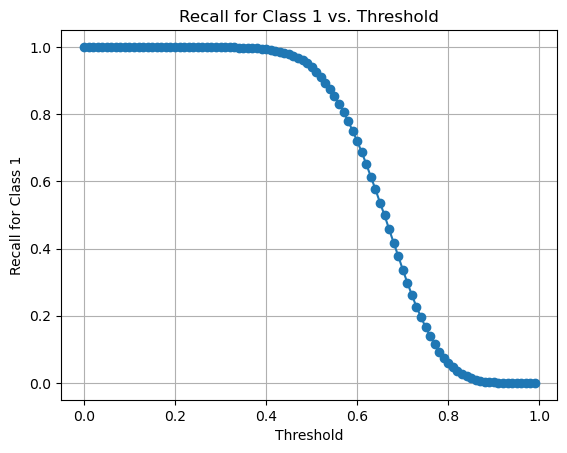

Accuracy: 0.6441644908616188
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.06      0.10     27822
           1       0.65      0.98      0.78     48778

    accuracy                           0.64     76600
   macro avg       0.63      0.52      0.44     76600
weighted avg       0.63      0.64      0.53     76600



In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, recall_score
import matplotlib.pyplot as plt
'''
# Sample dataframe
data = {
    'latitude': [34.05, 36.16, 40.71, 34.05, 36.16, 40.71],
    'longitude': [-118.24, -115.15, -74.00, -118.24, -115.15, -74.00],
    'temperature': [20, 25, 30, 22, 26, 28],
    'precipitation': [100, 50, 30, 110, 60, 40],
    'date': pd.date_range(start='1/1/2020', periods=6, freq='M'),
    'drought_flag': [0, 1, 0, 0, 1, 0]
}

df = pd.DataFrame(data)

# Feature selection
X = df[['latitude', 'longitude', 'temperature', 'precipitation']]
y = df['drought_flag']
'''
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating the logistic regression model
model = LogisticRegression()

# Training the model
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict_proba(X_test)

# Grid search on threshold
thresholds = np.arange(0.0, 1.0, 0.01)
recalls = []

for threshold in thresholds:
    y_class_pred = (y_pred[:, 1] >= threshold).astype(int)
    recall = recall_score(y_test, y_class_pred)
    recalls.append(recall)

# Plotting the recall for class 1 according to the threshold
plt.plot(thresholds, recalls, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Recall for Class 1')
plt.title('Recall for Class 1 vs. Threshold')
plt.grid(True)
plt.show()

# Evaluating the model at a specific threshold (e.g., 0.45)
threshold = 0.45
y_class_pred = (y_pred[:, 1] >= threshold).astype(int)
print("Accuracy:", accuracy_score(y_test, y_class_pred))
print("Classification Report:\n", classification_report(y_test, y_class_pred))


In [19]:
threshold = 0.41
y_class_pred = (y_pred[:, 1] >= threshold).astype(int)
print("Accuracy:", accuracy_score(y_test, y_class_pred))
print("Classification Report:\n", classification_report(y_test, y_class_pred))

Accuracy: 0.6401958224543081
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.03      0.05     27822
           1       0.64      0.99      0.78     48778

    accuracy                           0.64     76600
   macro avg       0.63      0.51      0.41     76600
weighted avg       0.63      0.64      0.51     76600



In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [21]:
'''
# Load your data
data = pd.read_csv('your_data.csv')

# Calculate annual sums/averages
data['annual_precipitation'] = data.groupby('year')['monthly_precipitation'].transform('sum')
data['annual_temperature'] = data.groupby('year')['monthly_temperature'].transform('mean')
data['annual_precipitation_delta'] = data.groupby('year')['precipitation_delta'].transform('sum')
data['annual_temperature_delta'] = data.groupby('year')['temperature_delta'].transform('mean')
'''


"\n# Load your data\ndata = pd.read_csv('your_data.csv')\n\n# Calculate annual sums/averages\ndata['annual_precipitation'] = data.groupby('year')['monthly_precipitation'].transform('sum')\ndata['annual_temperature'] = data.groupby('year')['monthly_temperature'].transform('mean')\ndata['annual_precipitation_delta'] = data.groupby('year')['precipitation_delta'].transform('sum')\ndata['annual_temperature_delta'] = data.groupby('year')['temperature_delta'].transform('mean')\n"

In [22]:
df['insee_2'].head()

201    59107
254    62899
255    62193
256    62645
257    59359
Name: insee_2, dtype: object

In [23]:
#X = df[[ 'latitude_1', 'longitude_1', 't2m_delta_1', 'tp_delta_1','swvl1_delta_1','swvl2_delta_1']]

In [24]:
df['year_2'].describe()

count    383000.000000
mean       2006.961347
std          10.166732
min        1990.000000
25%        1998.000000
50%        2007.000000
75%        2016.000000
max        2024.000000
Name: year_2, dtype: float64

In [25]:
df.isna().sum().sum()

0

In [26]:
import pandas as pd

def summarize_weather_data(df):
    # Group by the weather station (insee_2) and the year (year_2)
    yearly_summary = (
        df.groupby(['insee_2', 'year_2'])
        .agg(
            latitude_1=('latitude_1', 'first'),
            longitude_1=('longitude_1', 'first'),
            t2m_delta_1_yearly_sum=('t2m_delta_1', 'sum'),
            t2m_delta_1_yearly_mean=('t2m_delta_1', 'mean'),
            tp_delta_1_yearly_sum=('tp_delta_1', 'sum'),
            tp_delta_1_yearly_mean=('tp_delta_1', 'mean'),
            drought_yearly_flag=('drought_yearly_flag', 'first'),
        )
        .reset_index()
    )
    
    # Rename columns to match the required output format
    yearly_summary = yearly_summary.rename(columns={'insee_2': 'Code Commune_2'})
    
    # Select the desired columns in the specific order requested
    df_year = yearly_summary[[
        'latitude_1', 'longitude_1', 'Code Commune_2', 'year_2',
        't2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean',
        'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean',
        'drought_yearly_flag'
    ]]
    
    return df_year

# Example usage
df = summarize_weather_data(df)
print(df)


       latitude_1  longitude_1 Code Commune_2  year_2  t2m_delta_1_yearly_sum  \
0           46.00         5.25          01007    2008               -2.208984   
1           46.50         5.75          01014    2023               37.315011   
2           46.00         5.50          01022    2012               11.828172   
3           46.00         5.50          01022    2015               11.181001   
4           45.75         5.25          01027    2000                5.870675   
...           ...          ...            ...     ...                     ...   
25847       49.00         2.50          95585    2011               12.716064   
25848       49.00         2.00          95607    2024               19.020020   
25849       49.00         2.50          95612    2013               -4.291016   
25850       49.25         2.00          95627    1994                6.584159   
25851       49.00         2.50          95633    1999                5.457520   

       t2m_delta_1_yearly_m

In [27]:
df.isna().sum().sum()

0

In [28]:
# Calculate the sum based on the filtered DataFrame
#df['t2m_delta_1_yearly_sum'] = filtered_df.groupby(['year_2', 'Code Commune_2'])['t2m_delta_1'].transform('sum')

In [29]:
#df['t2m_delta_1_yearly_mean'] = df.groupby(['year_2','Code Commune_2'])['t2m_delta_1'].transform('mean')

In [30]:
#df['tp_delta_1_yearly_sum'] = df.groupby(['year_2','Code Commune_2'])['tp_delta_1'].transform('sum')

In [31]:
#df['tp_delta_1_yearly_mean'] = df.groupby(['year_2','Code Commune_2'])['tp_delta_1'].transform('mean')

In [32]:
df.columns

Index(['latitude_1', 'longitude_1', 'Code Commune_2', 'year_2',
       't2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean',
       'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean',
       'drought_yearly_flag'],
      dtype='object')

In [33]:
df_year = df[['latitude_1', 'longitude_1','Code Commune_2', 'year_2', 't2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean', 'drought_yearly_flag']].copy()

In [34]:
df_year.drop_duplicates(inplace=True)

In [35]:
#X = df_year[['latitude_1', 'longitude_1', 't2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]
#X = df_year[[ 't2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]

In [36]:
#Y=df_year['drought_yearly_flag']

In [37]:
import pandas as pd

def split_train_test_based_on_year(df_year, max_year_train, max_year_test=None):
    if max_year_test is None:
        max_year_test = max_year_train + 1
    
    # Split the dataset based on max_year_train and max_year_test
    train_df = df_year[df_year['year_2'] <= max_year_train]
    test_df = df_year[(df_year['year_2'] > max_year_train) & (df_year['year_2'] <= max_year_test)]

    # Create X and Y for train and test
    X_train = train_df[['t2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]
    Y_train = train_df['drought_yearly_flag']
    X_test = test_df[['t2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]
    Y_test = test_df['drought_yearly_flag']

    return X_train, X_test, Y_train, Y_test

# Example usage
# df_year = your_dataframe
max_year_train = 2018
X_train, X_test, Y_train, Y_test = split_train_test_based_on_year(df_year, max_year_train)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)


X_train: (20995, 4)
Y_train: (20995,)
X_test: (949, 4)
Y_test: (949,)


In [38]:
df.isna().sum()

latitude_1                 0
longitude_1                0
Code Commune_2             0
year_2                     0
t2m_delta_1_yearly_sum     0
t2m_delta_1_yearly_mean    0
tp_delta_1_yearly_sum      0
tp_delta_1_yearly_mean     0
drought_yearly_flag        0
dtype: int64

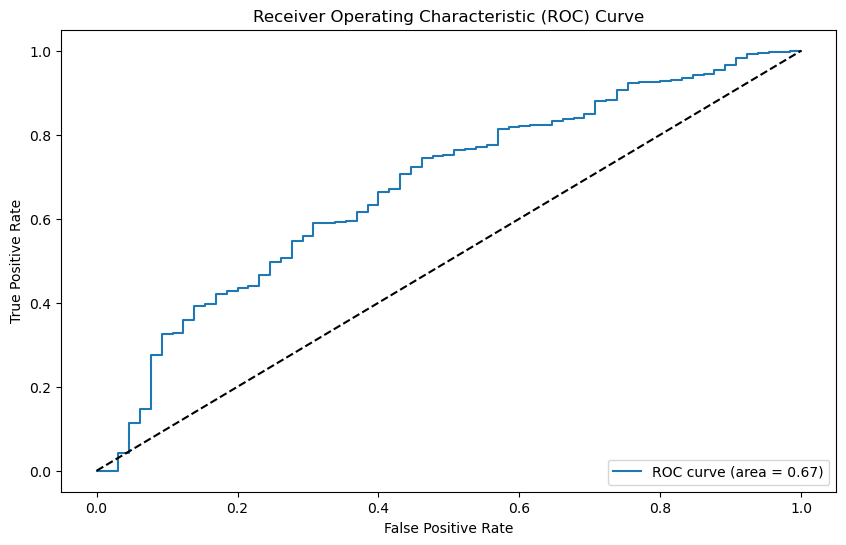

Best Threshold: 0.5595752071275409
Accuracy: 0.73


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Assuming df_year is already defined
#X = df_year[['latitude_1', 'longitude_1', 't2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]
#Y = df_year['drought_yearly_flag']

# Split the data into training and testing sets
#X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Create a pipeline with standardization and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

# Fit the model
pipeline.fit(X_train, Y_train)

# Predict probabilities
Y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob)
roc_auc = roc_auc_score(Y_test, Y_pred_prob)

# Find the best threshold
best_threshold = thresholds[np.argmax(tpr - fpr)]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Predict using the best threshold
Y_pred_best = (Y_pred_prob >= best_threshold).astype(int)

# Calculate accuracy
accuracy = accuracy_score(Y_test, Y_pred_best)
print(f'Best Threshold: {best_threshold}')
print(f'Accuracy: {accuracy:.2f}')


In [40]:
# Show classification report
print(classification_report(Y_test, Y_pred_best))

              precision    recall  f1-score   support

           0       0.13      0.54      0.22        65
           1       0.96      0.75      0.84       884

    accuracy                           0.73       949
   macro avg       0.55      0.64      0.53       949
weighted avg       0.90      0.73      0.80       949



In [41]:
'''

from sklearn.ensemble import RandomForestClassifier

# Create a pipeline with standardization and random forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Define parameter grid for grid search
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

# Perform grid search
grid_search = GridSearchCV(pipeline_rf, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, Y_train)

# Best parameters
best_params = grid_search.best_params_
print(f'Best Parameters: {best_params}')

# Predict probabilities
Y_pred_prob_rf = grid_search.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(Y_test, Y_pred_prob_rf)
roc_auc_rf = roc_auc_score(Y_test, Y_pred_prob_rf)

# Find the best threshold
best_threshold_rf = thresholds_rf[np.argmax(tpr_rf - fpr_rf)]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Predict using the best threshold
Y_pred_best_rf = (Y_pred_prob_rf >= best_threshold_rf).astype(int)

# Calculate accuracy
accuracy_rf = accuracy_score(Y_test, Y_pred_best_rf)
print(f'Best Threshold: {best_threshold_rf}')
print(f'Accuracy: {accuracy_rf:.2f}')

# Show classification report
print(classification_report(Y_test, Y_pred_best_rf))

'''

"\n\nfrom sklearn.ensemble import RandomForestClassifier\n\n# Create a pipeline with standardization and random forest\npipeline_rf = Pipeline([\n    ('scaler', StandardScaler()),\n    ('rf', RandomForestClassifier(random_state=42))\n])\n\n# Define parameter grid for grid search\nparam_grid = {\n    'rf__n_estimators': [50, 100, 200],\n    'rf__max_depth': [None, 10, 20, 30],\n    'rf__min_samples_split': [2, 5, 10],\n    'rf__min_samples_leaf': [1, 2, 4]\n}\n\n# Perform grid search\ngrid_search = GridSearchCV(pipeline_rf, param_grid, cv=5, scoring='roc_auc')\ngrid_search.fit(X_train, Y_train)\n\n# Best parameters\nbest_params = grid_search.best_params_\nprint(f'Best Parameters: {best_params}')\n\n# Predict probabilities\nY_pred_prob_rf = grid_search.predict_proba(X_test)[:, 1]\n\n# Calculate ROC curve and AUC\nfpr_rf, tpr_rf, thresholds_rf = roc_curve(Y_test, Y_pred_prob_rf)\nroc_auc_rf = roc_auc_score(Y_test, Y_pred_prob_rf)\n\n# Find the best threshold\nbest_threshold_rf = threshold

Best Parameters: {'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__n_estimators': 50, 'xgb__subsample': 0.8}


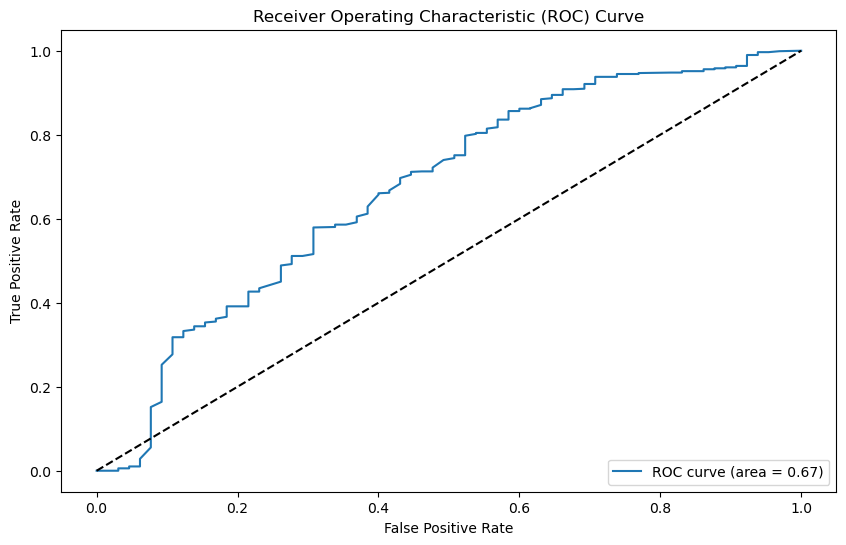

Best Threshold: 0.5459367632865906
Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.15      0.48      0.23        65
           1       0.95      0.80      0.87       884

    accuracy                           0.78       949
   macro avg       0.55      0.64      0.55       949
weighted avg       0.90      0.78      0.82       949



In [42]:


from xgboost import XGBClassifier

# Create a pipeline with standardization and XGBoost
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# Define parameter grid for grid search
param_grid_xgb = {
    'xgb__n_estimators': [50, 100, 200],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0]
}

# Perform grid search
grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, scoring='roc_auc')
grid_search_xgb.fit(X_train, Y_train)

# Best parameters
best_params_xgb = grid_search_xgb.best_params_
print(f'Best Parameters: {best_params_xgb}')

# Predict probabilities
Y_pred_prob_xgb = grid_search_xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(Y_test, Y_pred_prob_xgb)
roc_auc_xgb = roc_auc_score(Y_test, Y_pred_prob_xgb)

# Find the best threshold
best_threshold_xgb = thresholds_xgb[np.argmax(tpr_xgb - fpr_xgb)]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'ROC curve (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Predict using the best threshold
Y_pred_best_xgb = (Y_pred_prob_xgb >= best_threshold_xgb).astype(int)

# Calculate accuracy
accuracy_xgb = accuracy_score(Y_test, Y_pred_best_xgb)
print(f'Best Threshold: {best_threshold_xgb}')
print(f'Accuracy: {accuracy_xgb:.2f}')

# Show classification report
print(classification_report(Y_test, Y_pred_best_xgb))


              precision    recall  f1-score   support

           0       0.13      0.54      0.22        65
           1       0.96      0.75      0.84       884

    accuracy                           0.73       949
   macro avg       0.55      0.64      0.53       949
weighted avg       0.90      0.73      0.80       949



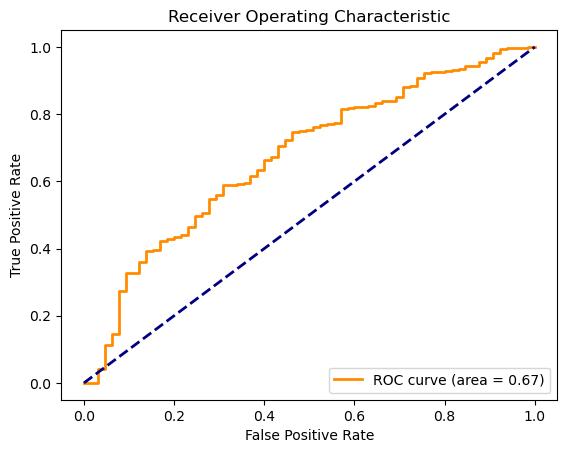

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Assuming df_year is your DataFrame
#X = df_year[['latitude_1', 'longitude_1', 't2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]
#Y = df_year['drought_yearly_flag']

# Split the data
#X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression())
])

# Fit the model
pipeline.fit(X_train, Y_train)

# Predict probabilities
Y_prob = pipeline.predict_proba(X_test)[:, 1]

# Find the best threshold
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
roc_auc = auc(fpr, tpr)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Predict with the best threshold
Y_pred = (Y_prob >= optimal_threshold).astype(int)

# Classification report
print(classification_report(Y_test, Y_pred))

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()



In [44]:
#!pip install optuna

In [75]:
import pandas as pd

def split_train_test_based_on_yearII(df_year, max_year_train, max_year_test=None):
    if max_year_test is None:
        max_year_test = max_year_train + 1
    
    # Split the dataset based on max_year_train and max_year_test
    train_df = df_year[df_year['year_2'] <= max_year_train]
    test_df = df_year[(df_year['year_2'] > max_year_train) & (df_year['year_2'] <= max_year_test)]

    # Create X and Y for train and test
    X_train = train_df[['latitude_1', 'longitude_1','t2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]
    Y_train = train_df['drought_yearly_flag']
    X_test = test_df[['latitude_1', 'longitude_1','t2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]
    Y_test = test_df['drought_yearly_flag']

    return X_train, X_test, Y_train, Y_test

# Example usage
# df_year = your_dataframe
max_year_train = 2020
X_train, X_test, Y_train, Y_test = split_train_test_based_on_yearII(df_year, max_year_train)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (22889, 6)
Y_train: (22889,)
X_test: (845, 6)
Y_test: (845,)


[I 2024-10-29 20:44:04,213] A new study created in memory with name: no-name-9b8bdfec-0735-4f40-b92c-f37a1d512a2e
[I 2024-10-29 20:44:07,258] Trial 0 finished with value: 0.48494329292139227 and parameters: {'n_estimators': 115, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.48494329292139227.
[I 2024-10-29 20:44:09,397] Trial 1 finished with value: 0.4794520547945205 and parameters: {'n_estimators': 140, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.48494329292139227.
[I 2024-10-29 20:44:17,698] Trial 2 finished with value: 0.492156862745098 and parameters: {'n_estimators': 193, 'max_depth': 29, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.492156862745098.
[I 2024-10-29 20:44:24,183] Trial 3 finished with value: 0.47759433962264153 and parameters: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 2 with value

Best parameters: {'n_estimators': 105, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 6}
Final Metric (1): 0.511518937914877


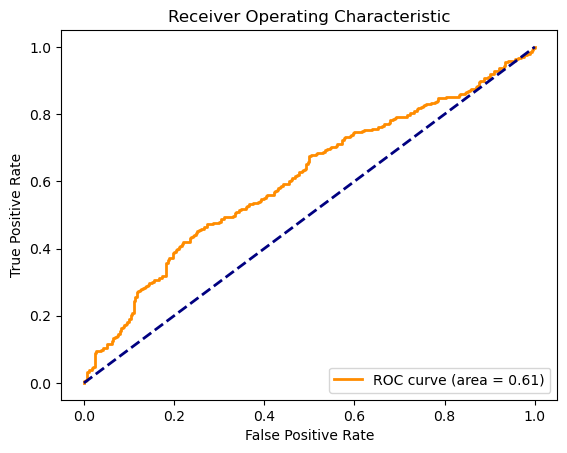

              precision    recall  f1-score   support

           0       0.42      0.73      0.53       290
           1       0.77      0.47      0.58       555

    accuracy                           0.56       845
   macro avg       0.59      0.60      0.56       845
weighted avg       0.65      0.56      0.57       845



In [76]:
import optuna
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report, average_precision_score, f1_score, balanced_accuracy_score, fbeta_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming df_year is your DataFrame
# X = df_year[['latitude_1', 'longitude_1', 't2m_delta_1_yearly_sum', 't2m_delta_1_yearly_mean', 'tp_delta_1_yearly_sum', 'tp_delta_1_yearly_mean']]
# Y = df_year['drought_yearly_flag']

# Split the data
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Define which metric to use
# Choices for metrics (ordered from preferred to least preferred for drought problem with unbalanced data where missing drought events is highly undesirable):
# 1: F2 Score - Puts more emphasis on recall, which is useful if missing drought events is particularly costly.
# 2: Average Precision Score - Focuses on precision and recall for the minority class, suitable for imbalanced datasets.
# 3: F1 Score - Balances precision and recall, useful when both false positives and false negatives are costly.
# 4: Balanced Accuracy Score - Averages recall obtained on each class, which helps when dealing with imbalanced datasets.
# 5: ROC AUC Score - Useful for evaluating the model's ability to distinguish between drought and non-drought states, but may not focus enough on the minority class.

metric_number = 1

# Dictionary to select the scoring metric based on the metric_number
metric_dict = {
    1: lambda y_true, y_pred: fbeta_score(y_true, y_pred, beta=2),
    2: lambda y_true, y_pred: average_precision_score(y_true, y_pred),
    3: lambda y_true, y_pred: f1_score(y_true, y_pred),
    4: lambda y_true, y_pred: balanced_accuracy_score(y_true, y_pred),
    5: lambda y_true, y_prob: auc(*roc_curve(y_true, y_prob)[:2])
}

# Define objective function for Optuna
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('random_forest', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        ))
    ])
    
    pipeline.fit(X_train, Y_train)
    Y_prob = pipeline.predict_proba(X_test)[:, 1]
    Y_pred = (Y_prob >= 0.5).astype(int)
    if metric_number == 5:
        return metric_dict[metric_number](Y_test, Y_prob)
    else:
        return metric_dict[metric_number](Y_test, Y_pred)

# Optimize hyperparameters
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Best parameters
best_params = study.best_params
print("Best parameters:", best_params)

# Train final model with best parameters
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('random_forest', RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        random_state=42
    ))
])

pipeline.fit(X_train, Y_train)
Y_prob = pipeline.predict_proba(X_test)[:, 1]
Y_pred = (Y_prob >= 0.5).astype(int)

# Calculate the chosen metric for the final model
if metric_number == 5:
    final_metric = metric_dict[metric_number](Y_test, Y_prob)
else:
    final_metric = metric_dict[metric_number](Y_test, Y_pred)

print(f"Final Metric ({metric_number}):", final_metric)

# Plot ROC curve if metric_number is 1 (ROC AUC)
if metric_number == 1:
    fpr, tpr, _ = roc_curve(Y_test, Y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

# Classification report
print(classification_report(Y_test, Y_pred))


In [77]:
# Identify misclassified examples
misclassified_indices = Y_test[Y_pred != Y_test].index

# Extract misclassified X_test and Y_test
X_test_misclassified = X_test.loc[misclassified_indices]
Y_test_misclassified = Y_test.loc[misclassified_indices]

# Print or work with the misclassified examples as needed
print("Misclassified X_test:")
print(X_test_misclassified)

print("Misclassified Y_test:")
print(Y_test_misclassified)


Misclassified X_test:
       latitude_1  longitude_1  t2m_delta_1_yearly_sum  \
34          46.00         5.00               -0.338588   
63          46.00         5.50                0.844820   
68          46.00         5.25                0.151367   
109         49.50         3.50                0.724935   
116         49.75         3.25                0.450335   
...           ...          ...                     ...   
25487       48.00         3.25                0.427316   
25586       47.50         7.00               -2.944429   
25597       47.75         6.75               -1.947126   
25652       48.50         2.00                0.877186   
25842       49.00         2.25                0.890578   

       t2m_delta_1_yearly_mean  tp_delta_1_yearly_sum  tp_delta_1_yearly_mean  
34                   -0.028216               0.006122                0.000510  
63                    0.070402               0.008556                0.000713  
68                    0.012614           

In [78]:
# Identify well-classified examples
well_classified_indices = Y_test[Y_pred == Y_test].index

# Extract well-classified X_test and Y_test
X_test_well_classified = X_test.loc[well_classified_indices]
Y_test_well_classified = Y_test.loc[well_classified_indices]

# Print or work with the well-classified examples as needed
print("Well-classified X_test:")
print(X_test_well_classified)

print("Well-classified Y_test:")
print(Y_test_well_classified)


Well-classified X_test:
       latitude_1  longitude_1  t2m_delta_1_yearly_sum  \
97          49.75         3.75               -0.226702   
162         49.50         4.00                0.447777   
163         50.00         3.75               -0.772089   
179         49.00         3.50                1.908250   
188         49.75         4.00               -0.964007   
...           ...          ...                     ...   
25636       48.50         2.25                1.134719   
25688       48.25         2.25                1.230422   
25720       48.75         2.25                0.795619   
25751       49.00         2.50                1.073242   
25774       48.75         2.50                1.097331   

       t2m_delta_1_yearly_mean  tp_delta_1_yearly_sum  tp_delta_1_yearly_mean  
97                   -0.018892               0.007057                0.000588  
162                   0.037315               0.007039                0.000587  
163                  -0.064341         

In [79]:
def plot_classification_map(X_test_well_classified, X_test_misclassified):
    # Get unique latitude and longitude points for well classified and misclassified
    well_classified_unique = X_test_well_classified[['latitude_1', 'longitude_1']].drop_duplicates()
    misclassified_unique = X_test_misclassified[['latitude_1', 'longitude_1']].drop_duplicates()
    
    # Create a map centered at the mean latitude and longitude
    center_lat = (well_classified_unique['latitude_1'].mean() + misclassified_unique['latitude_1'].mean()) / 2
    center_lon = (well_classified_unique['longitude_1'].mean() + misclassified_unique['longitude_1'].mean()) / 2
    map_ = folium.Map(location=[center_lat, center_lon], zoom_start=6)
    
    # Create feature groups for well-classified and misclassified points
    well_classified_group = folium.FeatureGroup(name='Well Classified', show=True)
    misclassified_group = folium.FeatureGroup(name='Misclassified', show=True)
    
    # Add well-classified points in green
    for _, row in well_classified_unique.iterrows():
        folium.CircleMarker(
            location=[row['latitude_1'], row['longitude_1']],
            radius=5,
            color='green',
            fill=True,
            fill_color='green',
            fill_opacity=0.7,
        ).add_to(well_classified_group)
    
    # Add misclassified points in yellow
    for _, row in misclassified_unique.iterrows():
        folium.CircleMarker(
            location=[row['latitude_1'], row['longitude_1']],
            radius=5,
            color='yellow',
            fill=True,
            fill_color='yellow',
            fill_opacity=0.7,
        ).add_to(misclassified_group)
    
    # Add the feature groups to the map
    well_classified_group.add_to(map_)
    misclassified_group.add_to(map_)
    
    # Add layer control to toggle between well-classified and misclassified points
    folium.LayerControl().add_to(map_)
    
    # Display the map
    return map_

how to build an annually indice, from monthly precipitations and temperature to predict drought (python dataframe)
I have also temperature_delta and precipitation_delta, a measure of monthly delta (in comparaison to a monthly mean of a reference period)
my y is a flag that says for each commune if it had drought that year.
Use logistic regression to make the prediction
I have also the longitude and latitude of the stations that took the measure and the name of the commune that it belongs to

why do you apply zscore and what does it do ?
what preprocessing do you apply for longitude, latitude

In [80]:
# Assuming X_well_classified and X_misclassified are provided
map_ = plot_classification_map(X_test_well_classified, X_test_misclassified)

In [81]:
map_

In [82]:
import pandas as pd
import folium
from folium.plugins import HeatMap
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display



def plot_side_by_side_maps(X_test_well_classified, Y_test_well_classified, X_test, Y_test):
    # Filter data to only include entries where Y = 1
    X_test_well_classified_Y1 = X_test_well_classified[Y_test_well_classified == 1][['latitude_1', 'longitude_1']]
    X_test_all_Y1 = X_test[Y_test == 1][['latitude_1', 'longitude_1']]
    
    # Create the figure with subplots for two mapbox maps in the same layout
    fig = go.Figure()

    # Add density map for well-classified points
    fig.add_trace(go.Densitymapbox(
        lat=X_test_well_classified_Y1['latitude_1'],
        lon=X_test_well_classified_Y1['longitude_1'],
        radius=10,
        colorscale='Viridis',
        name='Well Classified Y=1',
        showscale=False,
        z=None,
        subplot='mapbox1'
    ))

    # Add density map for all Y=1 points
    fig.add_trace(go.Densitymapbox(
        lat=X_test_all_Y1['latitude_1'],
        lon=X_test_all_Y1['longitude_1'],
        radius=10,
        colorscale='Viridis',
        name='All Y=1',
        showscale=False,
        z=None,
        subplot='mapbox2'
    ))

    # Update the layout to add two separate mapbox subplots
    fig.update_layout(
        mapbox1=dict(
            domain={'x': [0, 0.5], 'y': [0, 1]},
            style='open-street-map',
            center=dict(lat=X_test_all_Y1['latitude_1'].mean(), lon=X_test_all_Y1['longitude_1'].mean()),
            zoom=5,
        ),
        mapbox2=dict(
            domain={'x': [0.5, 1], 'y': [0, 1]},
            style='open-street-map',
            center=dict(lat=X_test_well_classified_Y1['latitude_1'].mean(), lon=X_test_well_classified_Y1['longitude_1'].mean()),
            zoom=5,
        ),
        height=600,
        title_text='Well Classified Y=1 vs All Y=1 (Density)',
        margin={"r":0, "t":50, "l":0, "b":0}
    )

    # Set each trace to use a different mapbox instance
    fig.data[0].subplot = 'mapbox1'
    fig.data[1].subplot = 'mapbox2'

    # Display the plot
    fig.show()

# Example usage
# df_year = summarize_weather_data(df)
# print(df_year)

# Assuming X_test_well_classified, Y_test_well_classified, X_test, and Y_test are provided
# plot_side_by_side_maps(X_test_well_classified, Y_test_well_classified, X_test, Y_test)


In [83]:
# Assuming X_test_well_classified, Y_test_well_classified, X_test_all, and Y_test_all are provided
plot_side_by_side_maps(X_test_well_classified, Y_test_well_classified, X_test, Y_test)

In [84]:
# Assuming X_test_well_classified, Y_test_well_classified, X_test_all, and Y_test_all are provided
plot_side_by_side_maps(X_test, Y_pred, X_test, Y_test)

In [85]:
'''

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Load your data
data = pd.read_csv('your_data.csv')

# Calculate annual sums/averages
data['annual_precipitation'] = data.groupby('year')['monthly_precipitation'].transform('sum')
data['annual_temperature'] = data.groupby('year')['monthly_temperature'].transform('mean')
data['annual_precipitation_delta'] = data.groupby('year')['precipitation_delta'].transform('sum')
data['annual_temperature_delta'] = data.groupby('year')['temperature_delta'].transform('mean')

# Drop duplicates to keep annual data
data = data.drop_duplicates(subset=['year', 'commune_name'])

# Features and target
features = data[['annual_precipitation', 'annual_temperature', 'annual_precipitation_delta', 'annual_temperature_delta', 'longitude', 'latitude']]
target = data['drought']  # Assuming you have a binary target column 'drought'

# Z-score normalization
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split data
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

'''

"\n\nimport pandas as pd\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import classification_report\n\n# Load your data\ndata = pd.read_csv('your_data.csv')\n\n# Calculate annual sums/averages\ndata['annual_precipitation'] = data.groupby('year')['monthly_precipitation'].transform('sum')\ndata['annual_temperature'] = data.groupby('year')['monthly_temperature'].transform('mean')\ndata['annual_precipitation_delta'] = data.groupby('year')['precipitation_delta'].transform('sum')\ndata['annual_temperature_delta'] = data.groupby('year')['temperature_delta'].transform('mean')\n\n# Drop duplicates to keep annual data\ndata = data.drop_duplicates(subset=['year', 'commune_name'])\n\n# Features and target\nfeatures = data[['annual_precipitation', 'annual_temperature', 'annual_precipitation_delta', 'annual_temperature_delta', 'longitude', 'latitude']]\ntarget = data['